In [1]:
import gc

import matplotlib.pyplot as plt 
import numpy as np
from tqdm import tqdm
import xarray as xr 

from profsea.emulator import GMSLREmulator

In [2]:
def load_mc(scenario: str, var_name: str) -> xr.DataArray:
    ds = xr.load_dataset(f"/Users/gregorymunday/Documents/Papers/ProFSea/ProFSea-tool/data/long_monte_carlo/{scenario}_{var_name}.nc")
    return ds.global_average_sea_level_change.values

In [3]:
scenarios = ['rcp26', 'rcp45', 'rcp85']
t_mid_input = {}
t_upper_input = {}

# Expansion
exp_mid_input = {}
exp_upper_input = {}
exp_lower_input = {}

# GMSLR
ar5_gmslr_mid = {}
ar5_gmslr_upper = {}
ar5_gmslr_lower = {}

# Antarctica
ar5_ant_mid = {}
ar5_ant_upper = {}
ar5_ant_lower = {}

# Greenland
ar5_green_mid = {}
ar5_green_upper = {}
ar5_green_lower = {}

# Glaciers
ar5_glac_mid = {}
ar5_glac_upper = {}
ar5_glac_lower = {}

# Landwater
ar5_land_mid = {}
ar5_land_upper = {}
ar5_land_lower = {}

for scenario in scenarios:
    # Temperature
    t_mid_input[scenario] = load_mc(scenario, "temperaturemid")
    t_upper_input[scenario] = load_mc(scenario, "temperatureupper")

    # Thermal expansion
    exp_mid_input[scenario] = load_mc(scenario, "expansionmid")
    exp_upper_input[scenario] = load_mc(scenario, "expansionupper")
    exp_lower_input[scenario] = load_mc(scenario, "expansionlower")

    # GMSLR
    ar5_gmslr_mid[scenario] = load_mc(scenario, "summid")
    ar5_gmslr_upper[scenario] = load_mc(scenario, "sumupper")
    ar5_gmslr_lower[scenario] = load_mc(scenario, "sumlower")

    # Antarctica
    ar5_ant_mid[scenario] = load_mc(scenario, "antnetmid")
    ar5_ant_upper[scenario] = load_mc(scenario, "antnetupper")
    ar5_ant_lower[scenario] = load_mc(scenario, "antnetlower")
    
    # Greenland
    ar5_green_mid[scenario] = load_mc(scenario, "greennetmid")
    ar5_green_upper[scenario] = load_mc(scenario, "greennetupper")
    ar5_green_lower[scenario] = load_mc(scenario, "greennetlower")

    # Glaciers
    ar5_glac_mid[scenario] = load_mc(scenario, "glaciermid")
    ar5_glac_upper[scenario] = load_mc(scenario, "glacierupper")
    ar5_glac_lower[scenario] = load_mc(scenario, "glacierlower")

    # Landwater
    ar5_land_mid[scenario] = load_mc(scenario, "landwatermid")
    ar5_land_upper[scenario] = load_mc(scenario, "landwaterupper")
    ar5_land_lower[scenario] = load_mc(scenario, "landwaterlower")

In [5]:
gmslr_output = {}
exp_output = {}
ant_output = {}
green_output = {}
glac_output = {}
land_output = {}
ar6_green_output = {}
ar6_land_output = {}
for scenario in tqdm(scenarios):
    emulator = GMSLREmulator(
        t_mid_input[scenario],
        exp_mid_input[scenario],
        scenario,
        2300,  # IF YEAR BEYOND 2100 AUTO SET PALMER METHOD TO TRUE
        input_ensemble=False,
        glaciermip=None,
        T_percentile_95=t_upper_input[scenario],
        OHC_percentile_95=exp_upper_input[scenario],
        output_percentiles=np.linspace(0, 100, 1001),
    )
    emulator.project()
    gmslr_output[scenario] = emulator.gmslr
    exp_output[scenario] = emulator.expansion
    ant_output[scenario] = emulator.antnet
    green_output[scenario] = emulator.greenland
    glac_output[scenario] = emulator.glacier
    land_output[scenario] = emulator.landwater
    ar6_green_output[scenario] = emulator.greenland_ar6
    ar6_land_output[scenario] = emulator.landwater_ar6
    gc.collect()


100%|██████████| 3/3 [04:44<00:00, 94.88s/it]


In [6]:
# GMSLR
gmslr_mid = {}
gmslr_upper = {}
gmslr_lower = {}

# Expansion
exp_mid = {}
exp_upper = {}
exp_lower = {}

# Antarctica
ant_mid = {}
ant_upper = {}
ant_lower = {}

# Greenland
green_mid = {}
green_upper = {}
green_lower = {}

# Glaciers
glac_mid = {}
glac_upper = {}
glac_lower = {}

# Landwater
land_mid = {}
land_upper = {}
land_lower = {}

# Greenland AR6
ar6_green_mid = {}
ar6_green_upper = {}
ar6_green_lower = {}

# Landwater AR6
ar6_land_mid = {}
ar6_land_upper = {}
ar6_land_lower = {}
for scenario in scenarios:
    # GMSLR
    gmslr_mid[scenario] = np.percentile(gmslr_output[scenario].T, 50, axis=1)
    gmslr_upper[scenario] = np.percentile(gmslr_output[scenario].T, 95, axis=1)
    gmslr_lower[scenario] = np.percentile(gmslr_output[scenario].T, 5, axis=1)

    # Expansion
    exp_mid[scenario] = np.percentile(exp_output[scenario].T, 50, axis=1)
    exp_upper[scenario] = np.percentile(exp_output[scenario].T, 95, axis=1)
    exp_lower[scenario] = np.percentile(exp_output[scenario].T, 5, axis=1)

    # Antarctica
    ant_mid[scenario] = np.percentile(ant_output[scenario].T, 50, axis=1)
    ant_upper[scenario] = np.percentile(ant_output[scenario].T, 95, axis=1)
    ant_lower[scenario] = np.percentile(ant_output[scenario].T, 5, axis=1)
    
    # Greenland
    green_mid[scenario] =  np.percentile(green_output[scenario].T, 50, axis=1)
    green_upper[scenario] = np.percentile(green_output[scenario].T, 95, axis=1)
    green_lower[scenario] = np.percentile(green_output[scenario].T, 5, axis=1)

    # Glaciers
    glac_mid[scenario] = np.percentile(glac_output[scenario].T, 50, axis=1)
    glac_upper[scenario] = np.percentile(glac_output[scenario].T, 95, axis=1)
    glac_lower[scenario] = np.percentile(glac_output[scenario].T, 5, axis=1)

    # Landwater
    land_mid[scenario] = np.percentile(land_output[scenario].T, 50, axis=1)
    land_upper[scenario] = np.percentile(land_output[scenario].T, 95, axis=1)
    land_lower[scenario] = np.percentile(land_output[scenario].T, 5, axis=1)

    # Greenland AR6
    ar6_green_mid[scenario] = np.percentile(ar6_green_output[scenario].T, 50, axis=1)
    ar6_green_upper[scenario] = np.percentile(ar6_green_output[scenario].T, 95, axis=1)
    ar6_green_lower[scenario] = np.percentile(ar6_green_output[scenario].T, 5, axis=1)

    ar6_land_mid[scenario] = np.percentile(ar6_land_output[scenario].T, 50, axis=1)
    ar6_land_upper[scenario] = np.percentile(ar6_land_output[scenario].T, 95, axis=1)
    ar6_land_lower[scenario] = np.percentile(ar6_land_output[scenario].T, 5, axis=1)

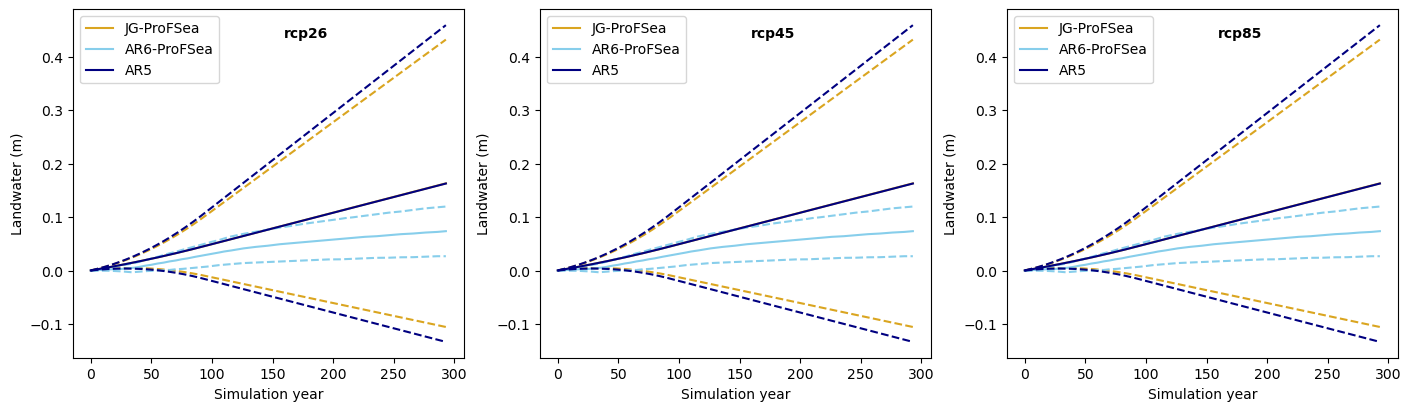

In [8]:
sim_comp_dict = {
    "gmslr": [gmslr_mid, gmslr_upper, gmslr_lower],
    "expansion": [exp_mid, exp_upper, exp_lower],
    "antarctica": [ant_mid, ant_upper, ant_lower],
    "greenland": [green_mid, green_upper, green_lower],
    "glaciers": [glac_mid, glac_upper, glac_lower],
    "landwater": [land_mid, land_upper, land_lower],
    "ar6_greenland": [ar6_green_mid, ar6_green_upper, ar6_green_lower],
    "ar6_landwater": [ar6_land_mid, ar6_land_upper, ar6_land_lower]
}
ar5_comp_dict = {
    "gmslr": [ar5_gmslr_mid, ar5_gmslr_upper, ar5_gmslr_lower],
    "expansion": [exp_mid_input, exp_upper_input, exp_lower_input],
    "antarctica": [ar5_ant_mid, ar5_ant_upper, ar5_ant_lower],
    "greenland": [ar5_green_mid, ar5_green_upper, ar5_green_lower],
    "glaciers": [ar5_glac_mid, ar5_glac_upper, ar5_glac_lower],
    "landwater": [ar5_land_mid, ar5_land_upper, ar5_land_lower]
}
component = "landwater"

fig = plt.figure(figsize=(14, 4), layout='constrained')

for i, scenario in enumerate(scenarios):
    ax = fig.add_subplot(1, 3, i + 1)

    # Simulation
    ax.plot(sim_comp_dict[component][0][scenario], color='goldenrod', label='JG-ProFSea')
    ax.plot(sim_comp_dict[component][1][scenario], color='goldenrod', ls='--')
    ax.plot(sim_comp_dict[component][2][scenario], color='goldenrod', ls='--')

    if component == "greenland":
        # AR6 simulation
        ax.plot(sim_comp_dict["ar6_greenland"][0][scenario], color='skyblue', label="AR6-ProFSea")
        ax.plot(sim_comp_dict["ar6_greenland"][1][scenario], color='skyblue', ls="--")
        ax.plot(sim_comp_dict["ar6_greenland"][2][scenario], color='skyblue', ls="--")

    elif component == "landwater":
        # AR6 sim
        ax.plot(sim_comp_dict["ar6_landwater"][0][scenario], color='skyblue', label="AR6-ProFSea")
        ax.plot(sim_comp_dict["ar6_landwater"][1][scenario], color='skyblue', ls="--")
        ax.plot(sim_comp_dict["ar6_landwater"][2][scenario], color='skyblue', ls="--")

    # AR5
    ax.plot(ar5_comp_dict[component][0][scenario], color='navy', label='AR5')
    ax.plot(ar5_comp_dict[component][1][scenario], color='navy', ls='--')
    ax.plot(ar5_comp_dict[component][2][scenario], color='navy', ls='--')
    ax.plot()
    # ax.set_ylim([-0.1, 7.0])
    ax.set_xlabel("Simulation year")
    if component == "gmslr":
        ax.set_ylabel(f"{component.upper()} (m)")
    else:
        ax.set_ylabel(f"{component[0].upper() + component[1:]} (m)")
    ax.text(0.54, 0.92, scenario, transform=ax.transAxes, weight='bold')
    ax.legend(loc='upper left')
fig.savefig(f"eval_plots/rcp_eval_ar5_ar6_{component}.png", dpi=300)
plt.show()
plt.close()